<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Deep-Neural-Network/blob/master/hw_1_multitask_counting_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project: Multitask Learning for Geometric Shape Classification and Counting**

## 1. Overview

In this project, you will design, implement, and evaluate a **multitask neural network** that performs **two tasks simultaneously**:

1. **Classification** – identify which pair of geometric shape types appears in a 28×28 binary image (135 possible configurations).
2. **Regression** – predict how many shapes of each type are present (6 regression targets).

This project focuses on **multi-task learning**, i.e., using one shared model to learn several related tasks at once. You will compare how adding an auxiliary task affects performance and training dynamics.

---

## 2. Dataset

You will use the **Geometric Shape Numbers (GSN)** dataset:

```bash
!wget https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
!unzip data_gsn.zip &> /dev/null
!rm data_gsn.zip
```

This will create a directory `data/` containing:

* **10,000 images** (28×28x1, grayscale)
* **labels.csv** – counts of each of six shape types per image

Each image contains exactly **two types** of geometric figures (out of six) and **10 shapes total**.

**Shape classes:**

| Index | Shape type     |
| ----: | -------------- |
|     0 | square         |
|     1 | circle         |
|     2 | triangle up    |
|     3 | triangle right |
|     4 | triangle down  |
|     5 | triangle left  |

Example row from `labels.csv`:

```
name,squares,circles,up,right,down,left
img_00000.png,0,0,0,4,0,6
```

Here, the image contains **4 right-pointing triangles** and **6 left-pointing triangles**.

**Split:**

* Training: first 9,000 samples
* Validation: last 1,000 samples

Examples:
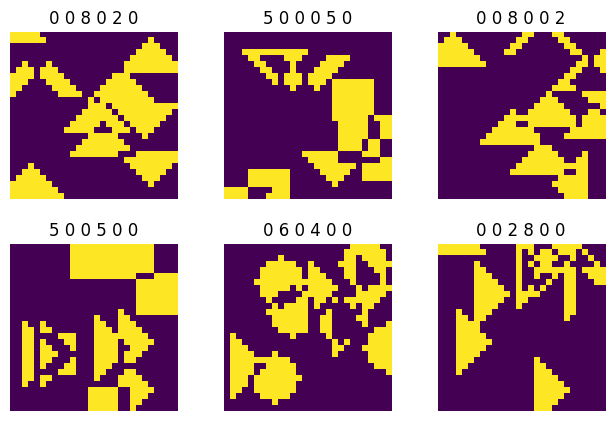

---

## 3. Tasks and objectives

You must design a **multitask deep learning system** that:

1. **Classifies** each image into one of **135 possible configurations**, representing:

   * which **two shape classes** appear, and
   * how their counts (1–9) sum to 10.

   → Example: "3 circles + 7 squares" is one configuration class.

2. **Regresses** the number of shapes of each type (a 6-dimensional real-valued output).

3. Combines both objectives in a **joint loss** function (Hint: losses are implemented in PyTorch):


$$ Loss = \text{NLLLoss(classification)} + \lambda_{\text{cnt}} \cdot \text{SmoothL1Loss(regression)}
$$

---

## 4. Model requirements

### Architecture constraints

You must use **exactly this feature extractor (backbone)**:

```python
nn.Sequential(
    nn.Conv2d(1, 8, 3, stride=1, padding=1), nn.ReLU(),
    nn.Conv2d(8, 16, 3, stride=1, padding=1), nn.ReLU(),
    nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(),
    nn.Conv2d(32, 64, 3, stride=1, padding=1), nn.ReLU(),
    nn.Flatten(start_dim=1),
    nn.Linear(64 * 28 * 28, 256), nn.ReLU()
)
```

Then add **two separate heads**:

* `head_cls`: outputs log-probabilities for 135 classes
* `head_cnt`: outputs 6 regression values (counts)

The model must return two outputs: `(log_probs, counts)`.

You may add dropout or batch normalization inside the heads, **but you must not modify the backbone**.

---

## 5. Training setup

* Optimizer: **Adam**, learning rate = 1e-3
* Epochs: up to **100** (use **early stopping**)
* Batch sizes: **64** (train), **1000** (validation)
* Device: GPU allowed for Notebook, but your **final code must run on GPU within ~30 minutes**
* Random seed: set `torch.manual_seed(1)` for reproducibility
* Split: **exactly 9,000 train / 1,000 validation**


---

## 6. Data preprocessing and augmentation

You must implement a **PyTorch `Dataset` class** that:

* Reads `labels.csv`
* Loads the corresponding image (from `data/`)
* Returns both:
  * the image (as a tensor)
  * the labels (counts for 6 shapes)
* Optionally applies transformations

### Required augmentations

You must implement **at least three** of the following:

1. Random horizontal flip
2. Random vertical flip
3. Random 90° rotation (must correctly rotate orientation labels: up → right → down → left)
4. Random brightness/contrast (mild)
5. Gaussian noise
6. Random erasing (small areas only)


---

## 7. Evaluation metrics

Implement and report the following metrics on the validation set:

### (a) **Classification (135-way)**

* Top-1 accuracy
* Macro F1-score
* Per-pair accuracy (aggregate by unordered shape pair, e.g. {circle, up})

### (b) **Regression (6-D counts)**

* RMSE per class and overall
* MAE per class and overall

Also plot:

* Training and validation losses
* Validation accuracy and RMSE over epochs

**Important**: This task is not about finding the best architecture; we expect at least 50% accuracy, but achieving results higher than that will not affect the grade for the assignment**.


---

## 8. Experiments and analysis

You must train and compare **three model settings**:

| Setting | Description                                      |
| :------ | :----------------------------------------------- |
| 1       | **Classification-only:** λ_cnt = 0               |
| 2       | **Regression-only:** classification loss ignored |
| 3       | **Multitask:** λ_cnt = with your choose          |

For each experiment:

* Train until early stopping
* Record loss, accuracy, RMSE, and runtime
* Compare results and explain how λ influences learning
* Discuss whether multitask learning improves the main tasks


---

## 9. Final deliverables

You must submit .zip project with:

1. **Code** (`.ipynb` or `.py`) that:

   * Downloads and extracts the dataset
   * Defines dataset, dataloaders, model, loss, training loop, evaluation, and plotting
   * Can run start-to-end without interaction, and finishes within 30 minutes on Colab T4 GPUs
   * Includes three experiment configurations

2. **Report (2–4 pages, PDF)** including:
   * Section on (EDA) Exploratory Data Analysis in your report: no more than 3 graphs or tables describing the data set.
   * Model architecture
   * Description and justification of augmentations
   * Results table (loss, accuracy, RMSE for all runs)
   * Learning curves
   * Discussion on multitask effects

3. **README.md**:

   * Link to Colab version of task for fast replication.
   * Approximate runtime and resource requirements

---

## 10. Grading rubric

Component	Description	Points
1. Implementation correctness	Correct use of the fixed backbone, two-headed model, and proper training loop (classification + regression).	30%
2. Data & augmentations	Proper dataset loading, preprocessing, and at least three augmentations with brief justification.	20%
3. Evaluation & experiments	Correct computation of metrics (accuracy, F1, RMSE) and completion of all three λ configurations (λ=0, regression-only, your choice λ).	30%
4. Report & analysis
A clear separation of concerns (e.g. headers in notebooks, modules in code) and concise 2–4 page report with results tables, learning curves, confusion matrix, and short discussion on multitask effects and error examples.
20%

###### Readability and modularity will be considered within each grading component. Clear structure (headers in notebooks, docstrings, modular code) significantly improves evaluation speed. Emphasize using clear headers to help reviewers navigate efficiently.
---

In [2]:
!wget  https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
!unzip data_gsn.zip &> /dev/null
!rm data_gsn.zip

--2025-11-11 16:47:32--  https://github.com/marcin119a/data/raw/refs/heads/main/data_gsn.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/marcin119a/data/refs/heads/main/data_gsn.zip [following]
--2025-11-11 16:47:32--  https://raw.githubusercontent.com/marcin119a/data/refs/heads/main/data_gsn.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5544261 (5.3M) [application/zip]
Saving to: ‘data_gsn.zip’

data_gsn.zip        100%[===================>]   5.29M  --.-KB/s    in 0.1s    

2025-11-11 16:47:33 (43.0 MB/s) - ‘data_gsn.zip’ saved [5544261/5544261]



In [3]:
# torch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch import Tensor
import torch.nn.functional as F

# the rest of imports
import pandas as pd
import numpy as np
import os
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

In [4]:
# setting seed
torch.manual_seed(1)

In [5]:
# choosing device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [6]:
data_folder = "data"
csv_file_path = os.path.join(data_folder, "labels.csv")
batch_size = 64

In [28]:
# implementing Dataset class in PyTorch

class GeometricShapesDataset(Dataset):

  def __init__(self, csv_file_path, root_directory, mode = "train", transform = None):
    """
    Parameters:
      csv_file_path - path to file labels.csv containig labels for the dataset
      root_directory - path to folder containing images
      mode - parameter responsible for determining whether we use training mode (first 9000 images; = "train") or we use validation mode (last 1000 images; = "validation")
      transform - parameter responsible for choice of augumentation; EXACT DESIGN IN PROGRESS
    """
    self.root_directory = root_directory
    self.transform = transform


    labels = pd.read_csv(csv_file_path)

    if mode == "train":
      self.labels_df = labels[:9000]
    elif mode == "validation":
      self.labels_df = labels[-1000:]
    else:
      raise ValueError("Parameter 'mode' should be equal to 'train' or 'validation'.")

    # self.len = len(self.labels_df) # replaced by __len__ method

  def __len__(self):
     return len(self.labels_df)

  def __getitem__(self, index):
    """
    Method introduced to get data from labels_df.
    """
    #row = self.labels_df[index] # resulted in error
    row = self.labels_df.iloc[index]

    # obtaining image
    image_name = row["name"]
    image_path = os.path.join(self.root_directory, image_name)
    image = Image.open(image_path).convert("L") # without ".convert("L")" the image wouldn't be converted to grayscale and the numbers of channels wouldn't match on training, resulting in an error

    # coverting row to pytorch tensor
    counts_tensor = torch.tensor(row[1:].values.astype(np.float32))

    ### Addressing the random 90 degrees rotation of the image
    # we have to add the part of code that will change the labels
    if self.transform is not None:
      # only some random part of images will be rotated; we set threshold at 0.3
      if torch.rand(1) < 0.3:
        # rotate the image
        image = image.transpose(Image.ROTATE_90)

        # updating the labels
        up_count = counts_tensor[2].item()
        right_count = counts_tensor[3].item()
        down_count = counts_tensor[4].item()
        left_count = counts_tensor[5].item()

        counts_tensor[2] = left_count
        counts_tensor[3] = up_count
        counts_tensor[4] = right_count
        counts_tensor[5] = down_count

      ### Addressing the horizontal flip
      if torch.rand(1) < 0.3:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)

        # now only 'triangle left' and 'triangle right' labels require switching

        right_count = counts_tensor[3].item()
        left_count = counts_tensor[5].item()

        counts_tensor[3] = left_count
        counts_tensor[5] = right_count

    # assigning counts tensor to correct class; to do it we use _map_counts_to_class_label method that is defined later
    class_label = self._map_counts_to_class_label(counts_tensor)

    # transforming image
    # it requires defining the transformations (it will be done by other method, which will be defined later)
    if self.transform is not None:
      image = self.transform(image)
    else:
      image = transforms.ToTensor()(image)

    return image, counts_tensor, class_label

  def _map_counts_to_class_label(self, counts_tensor):
    """
    Function responsible for mapping 'counts_tensor' to one of the 135 classification classes.
    """

    index_1 = (torch.where(counts_tensor > 0)[0][0]).item()
    index_2 = (torch.where(counts_tensor > 0)[0][1]).item()
    count_1 = counts_tensor[index_1].item()
    count_2 = counts_tensor[index_2].item()

    # defining the 135 classes

    # first introduce part responsible for encoding what 2 classes of shapes are taken
    pairs = sorted([(i, j) for i in range(6) for j in range(i+1, 6)]) # 15 distinct pairs
    current_pair = tuple(sorted((index_1, index_2)))
    pair_class = pairs.index(current_pair)

    # now we define the part responsible for encoding what is the distribution of count_1 and count_2
    # let us introduce mapping: (1, 9) -> class 0, (2, 8) -> class 1, ..., (9, 1) -> class 8; 9 classes in total
    # therefore we may use formula
    distribution_class = int(counts_tensor[current_pair[0]].item()) - 1

    # final label
    label = (pair_class * 9) + distribution_class # 15*9 = 135 distinct classes

    return torch.tensor(label, dtype = torch.int64)




Shapes counts: 
squares    14923
circles    15490
up         14811
right      15069
down       15226
left       14481
dtype: int64


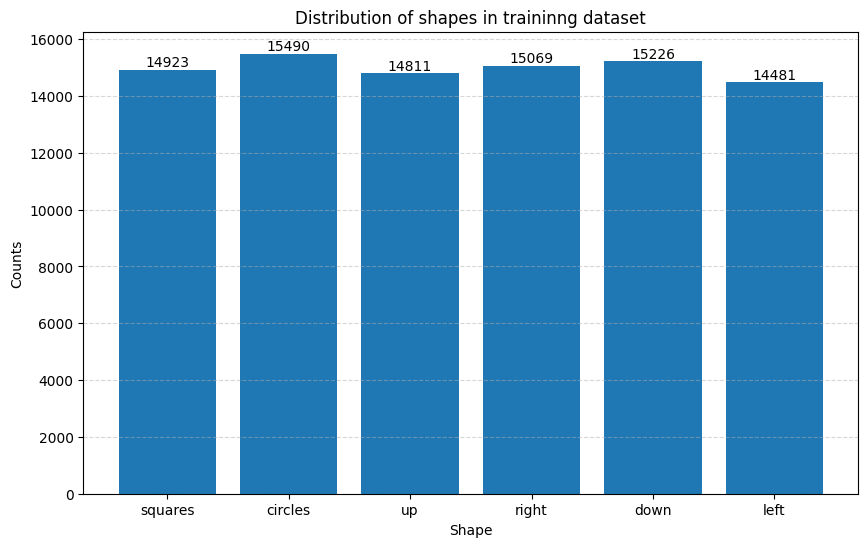

/tmp/ipython-input-1703546092.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labels_train["class_135"] = labels_train.apply(map_row_to_class, axis = 1)


Metrics:
count    105.000000
mean      85.714286
std        8.627677
min       56.000000
25%       80.000000
50%       86.000000
75%       92.000000
max      105.000000
Name: count, dtype: float64
Most common classes:
class_135
88    105
59    104
92    101
97     99
23     98
Name: count, dtype: int64
Rarest classes:
class_135
24     70
48     69
103    68
10     65
37     56
Name: count, dtype: int64


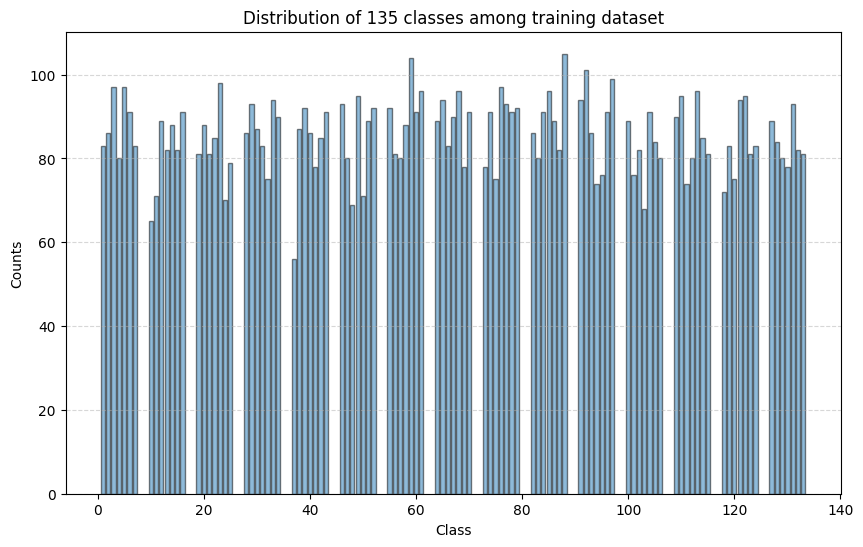

In [56]:
# Explanatory Data Analysis
labels = pd.read_csv(csv_file_path)

labels_train = labels[:9000]

# counting shape types
shapes_columns = ["squares", "circles", "up", "right", "down", "left"]
shapes_df = labels_train[shapes_columns]
shapes_counts = shapes_df.sum()
print("Shapes counts: ")
print(shapes_counts)

# Plot 1 showing distribution of shapes
plt.figure(figsize=(10,6))
bars = plt.bar(shapes_counts.index, shapes_counts.values)
plt.bar_label(bars)
plt.title("Distribution of shapes in traininng dataset")
plt.xlabel("Shape")
plt.ylabel("Counts")
plt.grid(axis = "y", linestyle="--", alpha = 0.5)
plt.savefig("EDA_plot_1.jpg")
plt.show()

# mapping rows to one of the 135 classses (similiar logic to the one used to GeometricShapesDataset)
pairs = sorted([(i, j) for i in range(6) for j in range(i + 1, 6)])

def map_row_to_class(row):
    vector_counts = row[shapes_columns]
    index_1 = np.where(vector_counts > 0)[0][0]
    index_2 = np.where(vector_counts > 0)[0][1]

    current_pair = tuple(sorted((index_1, index_2)))
    pair_class = pairs.index(current_pair)

    count_for_first_index = vector_counts.iloc[current_pair[0]]
    distribution_class = int(count_for_first_index) - 1

    label = (pair_class * 9) + distribution_class
    return label

# creating new column representing one of 135 classes
labels_train["class_135"] = labels_train.apply(map_row_to_class, axis = 1)

# counting appearences of each class
class_counts = labels_train["class_135"].value_counts()

# print some information
print("Metrics:")
print(class_counts.describe())
print("Most common classes:")
print(class_counts.head(5))
print("Rarest classes:")
print(class_counts.tail(5))

# Plot 2
plt.figure(figsize=(10,6))
plt.bar(class_counts.index, class_counts.values,  edgecolor='black', alpha=0.5)
plt.title("Distribution of 135 classes among training dataset")
plt.xlabel("Class")
plt.ylabel("Counts")
plt.grid(axis = "y", linestyle="--", alpha = 0.5)
plt.savefig("EDA_plot_2.jpg")
plt.show()


In [19]:
### small testing part for checking outputs

x = torch.tensor([0,0,1,0,0,2])
y = np.array([0,0,1,0,0,2])
counts_tensor = torch.tensor(y.astype(np.float32))
index_1 = (torch.where(counts_tensor > 0)[0][0]).item()
count_1 = counts_tensor[index_1].item()
count_1

1.0

In [20]:
# Testing part for class GeometricShapesDataset(Dataset)

# Test 1
train_dataset = GeometricShapesDataset(csv_file_path=csv_file_path, root_directory=data_folder, mode="train")
validation_dataset = GeometricShapesDataset(csv_file_path=csv_file_path, root_directory=data_folder, mode="validation")

print("Test 1")
print(f"Size of training dataset: {len(train_dataset)}")
print(f"Size of training dataset: {len(validation_dataset)}")


# now we'll test with paramater 'transfrom' using placeholder

placeholder_transform = transforms.ToTensor()

# Test 2
train_dataset = GeometricShapesDataset(csv_file_path=csv_file_path, root_directory=data_folder, mode="train", transform = placeholder_transform)
validation_dataset = GeometricShapesDataset(csv_file_path=csv_file_path, root_directory=data_folder, mode="validation", transform = placeholder_transform)

print("Test 2")
print(f"Size of training dataset: {len(train_dataset)}")
print(f"Size of training dataset: {len(validation_dataset)}")


# Test 3
# create DataLoader
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size = 1000, shuffle=False)


for images, counts, labels in train_dataloader:
    print("Test 3")
    # Verfification of shapes and types of images, count, labels in one batch
    print(f"Image batch: shape={images.shape}, type={images.dtype}")
    print(f"Counts batch: shape={counts.shape}, type={counts.dtype}")
    print(f"Labels batch: shape={labels.shape}, type={labels.dtype}")

    print("Example")
    print(f"Counts: {counts[0]}")
    print(f"Labels:  {labels[0]}")

    break


Test 1
Size of training dataset: 9000
Size of training dataset: 1000
Test 2
Size of training dataset: 9000
Size of training dataset: 1000
Test 3
Image batch: shape=torch.Size([64, 1, 28, 28]), type=torch.float32
Counts batch: shape=torch.Size([64, 6]), type=torch.float32
Labels batch: shape=torch.Size([64]), type=torch.int64
Example
Counts: tensor([0., 3., 0., 7., 0., 0.])
Labels:  56


In [21]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # backbone
    self.backbone = nn.Sequential(
      nn.Conv2d(1, 8, 3, stride=1, padding=1),
      nn.ReLU(),
      nn.Conv2d(8, 16, 3, stride=1, padding=1),
      nn.ReLU(),
      nn.Conv2d(16, 32, 3, stride=1, padding=1),
      nn.ReLU(),
      nn.Conv2d(32, 64, 3, stride=1, padding=1),
      nn.ReLU(),
      nn.Flatten(start_dim=1),
      nn.Linear(64 * 28 * 28, 256),
      nn.ReLU()
    )

    # head_cls and head_cnt
    self.head_cls = nn.Linear(256, 135)
    self.head_cnt = nn.Linear(256, 6)

  def forward(self, x: Tensor) -> Tensor:
    x = self.backbone(x) # (batch_size, 256)
    logits_cls = self.head_cls(x)
    counts_cnt = self.head_cnt(x)
    log_probs_cls = F.log_softmax(logits_cls, dim=1)

    return log_probs_cls, counts_cnt




In [22]:
# inicializing model
model = Model().to(device)

# defining loss functions
loss_cls = nn.NLLLoss()
loss_cnt = nn.SmoothL1Loss()

# let lambda be 1, later it will be changed
lambda_cnt = 1.0

# setting learning rate
learning_rate = 1e-3

# inicializing optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# setting maximum number of epochs
n_epochs = 3

In [23]:
# sample code with only 2 epochs to test whether the net trains properly; below there is a version with n_epochs = 100
n_epochs = 2
train_dataset = GeometricShapesDataset(csv_file_path=csv_file_path, root_directory=data_folder, mode="train")
validation_dataset = GeometricShapesDataset(csv_file_path=csv_file_path, root_directory=data_folder, mode="validation")

train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size = 1000, shuffle=False)

# parameters for early stopping mechanism
patience = 5
epochs_without_improvement = 0
best_validation_loss = float('inf')

# creating lists that will be responsible for storing data that will enable us to create plots about learnig curves
history_avg_train_loss = []
history_total_train_loss = []
history_avg_validation_loss = []
history_total_validation_loss = []
history_validation_accuracy = []
history_validation_f1_score = []
history_validation_per_pair_accuracy = []
history_validation_rmse = []
history_validation_mae = []
history_validation_rmse_per_class = []
history_validation_mae_per_class = []

# setting training mode
model.train()

# training loop
for i in range(n_epochs):
  # TRAINING SECTION
  total_train_loss = 0.0

  for batch_index, (images, counts, labels) in enumerate(train_dataloader):
    images, counts, labels = images.to(device), counts.to(device), labels.to(device)

    optimizer.zero_grad()
    output_cls, output_cnt = model(images)
    loss = loss_cls(output_cls, labels) + lambda_cnt * loss_cnt(output_cnt, counts)
    loss.backward()
    optimizer.step()
    total_train_loss = total_train_loss + loss.item()

  avg_train_loss = total_train_loss / len(train_dataloader)
  print(f"Epoch {i+1}: Average training loss = {avg_train_loss}")

  # updating history train loss lists
  history_avg_train_loss.append(avg_train_loss)
  history_total_train_loss.append(total_train_loss)

  # VALIDATION SECTION
  # switching to evaluation mode
  model.eval()

  # setting up for validation
  total_validation_loss = 0.0
  all_true_labels = []
  all_prediction_labels = []
  all_true_counts = []
  all_prediction_counts = []

  with torch.no_grad():
      for images, counts, labels in validation_dataloader:
        images, counts, labels = images.to(device), counts.to(device), labels.to(device)

        output_cls, output_cnt = model(images)
        loss = loss_cls(output_cls, labels) + lambda_cnt * loss_cnt(output_cnt, counts)
        total_validation_loss = total_validation_loss + loss.item()


        # saving outputs to lists
        # added '.cpu()' to prevent error while working with numpy on gpu
        # saving for cnt part
        all_prediction_counts.append(output_cnt.cpu())
        all_true_counts.append(counts.cpu())

        # saving for cls part
        predicted_labels = output_cls.argmax(dim=1)
        all_prediction_labels.append(predicted_labels.cpu())
        all_true_labels.append(labels.cpu())

  avg_validation_loss = total_validation_loss / len(validation_dataloader)

  # combing results saved in the lists
  validation_prediction_labels = torch.cat(all_prediction_labels) # tensor (1000) with all prediction labels
  validation_true_labels = torch.cat(all_true_labels)
  validation_prediction_counts = torch.cat(all_prediction_counts) # tensor (1000, 6) with all prediction counts
  validation_true_counts = torch.cat(all_true_counts)
  # these tensors will be used to calculate metrics

  # converting tensors to numpy format
  validation_prediction_labels_np = validation_prediction_labels.numpy()
  validation_true_labels_np = validation_true_labels.numpy()
  validation_prediction_counts_np = validation_prediction_counts.numpy()
  validation_true_counts_np = validation_true_counts.numpy()


  # a) calcuating metrics for classification part
  # calculating top1 accuracy
  validation_accuracy = accuracy_score(validation_true_labels_np, validation_prediction_labels_np)

  # calculating f1 score
  # introduced average = "macro", since otherwise it would result in error, because we are in multiclass environment
  validation_f1 = f1_score(validation_true_labels_np, validation_prediction_labels_np, average = 'macro', zero_division=0)

  # calculating 'per-pair accuracy'
  # it will be a bit more complicated than calculating f1 and accuracy
  # we can extract 'pair group' by dividing by 9
  true_pair_group = validation_true_labels_np // 9
  prediction_pair_group = validation_prediction_labels_np // 9

  # count cases when true_pair_group is equal to prediction_pair_group
  correct_pairs = (true_pair_group == prediction_pair_group)

  # compute 'per-pair accuracy'
  validation_per_pair_accuracy = correct_pairs.mean()

  print(f"Validation metircs: top-1 accuracy = {validation_accuracy}, f1 score = {validation_f1}, per-pair accuracy = {validation_per_pair_accuracy}")

  # b) calculating metrics for regression part
  # RMSE
  mse_loss = nn.MSELoss()
  validation_rmse = torch.sqrt(torch.tensor(mse_loss(validation_true_counts, validation_prediction_counts).item())).item()

  # MAE
  mae_loss = nn.L1Loss()
  validation_mae = mae_loss(validation_true_counts, validation_prediction_counts).item()

  # now we have to compute RMSE and MAE per class
  # to do this we implement new errors
  squared_errors = (validation_prediction_counts - validation_true_counts) ** 2 # (1000, 6)
  absolute_errors = torch.abs(validation_prediction_counts - validation_true_counts) # (1000, 6)

  # we take mean over dim = 0
  mean_squared_errors = torch.mean(squared_errors, dim = 0) # (6)
  mean_absolute_errors = torch.mean(absolute_errors, dim = 0) # (6)

  validation_rmse_per_class = torch.sqrt(mean_squared_errors)
  validation_mae_per_class = mean_absolute_errors

  history_validation_rmse_per_class.append(validation_rmse_per_class)
  history_validation_mae_per_class.append(validation_mae_per_class)

  print(f"Validation metircs: RMSE (overall) = {validation_rmse}, MAE (overall)= {validation_mae}")
  print(f"Validation metircs: RMSE (per class) = {validation_rmse_per_class}, MAE (per class)= {validation_mae_per_class}")

  # updating history validation lists
  history_avg_validation_loss.append(avg_validation_loss)
  history_total_validation_loss.append(total_validation_loss)
  history_validation_accuracy.append(validation_accuracy)
  history_validation_f1_score.append(validation_f1)
  history_validation_per_pair_accuracy.append(validation_per_pair_accuracy)
  history_validation_rmse.append(validation_rmse)
  history_validation_mae.append(validation_mae)


  # EARLY STOPPING mechanism
  # the mechanism works as follows: we assume that we may wait no more that 'patience' epochs (in our case 'patience'=5) for improvement of avg_validation_loss
  # if for 'patience' epochs we observe no improvement for this metric, then we stop training
  if avg_validation_loss < best_validation_loss:
    best_validation_loss = avg_validation_loss
    epochs_without_improvement = 0
  else:
    epochs_without_improvement += 1
  # checking if we have already run out of patience
  if epochs_without_improvement >= patience:
    # executing early stopping
    break

  # switching back to training mode
  model.train()



Epoch 1: Average training loss = 6.099677268494951
Validation metircs: top-1 accuracy = 0.021, f1 score = 0.003964633988873287, per-pair accuracy = 0.112
Validation metircs: RMSE (overall) = 2.6817846298217773, MAE (overall)= 1.7547296285629272
Validation metircs: RMSE (per class) = tensor([2.4064, 2.7476, 2.8788, 2.6399, 2.7623, 2.6315]), MAE (per class)= tensor([1.6174, 1.8373, 1.8705, 1.7958, 1.6891, 1.7183])
Epoch 2: Average training loss = 4.81296362437255
Validation metircs: top-1 accuracy = 0.133, f1 score = 0.07224706496458541, per-pair accuracy = 0.524
Validation metircs: RMSE (overall) = 1.6250481605529785, MAE (overall)= 1.1024887561798096
Validation metircs: RMSE (per class) = tensor([1.2478, 2.5899, 1.4104, 1.5033, 1.2421, 1.3373]), MAE (per class)= tensor([0.8402, 1.8013, 1.0284, 1.1463, 0.8670, 0.9317])


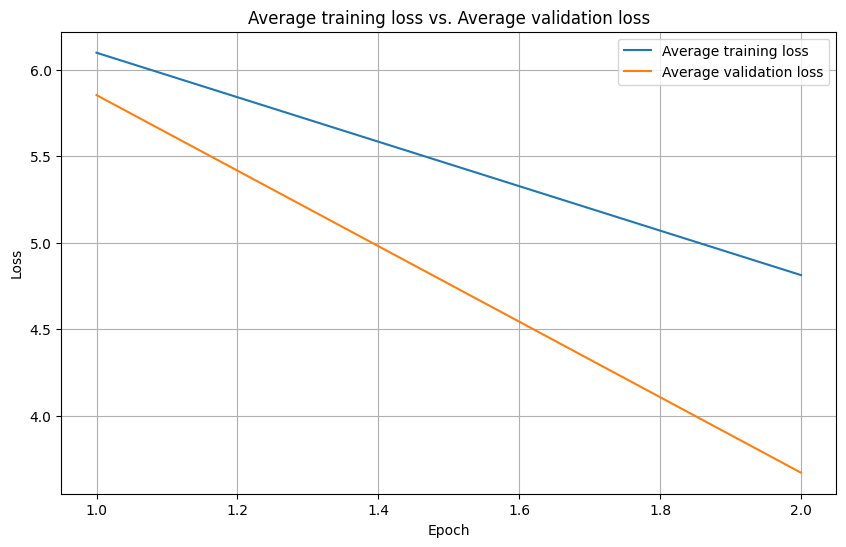

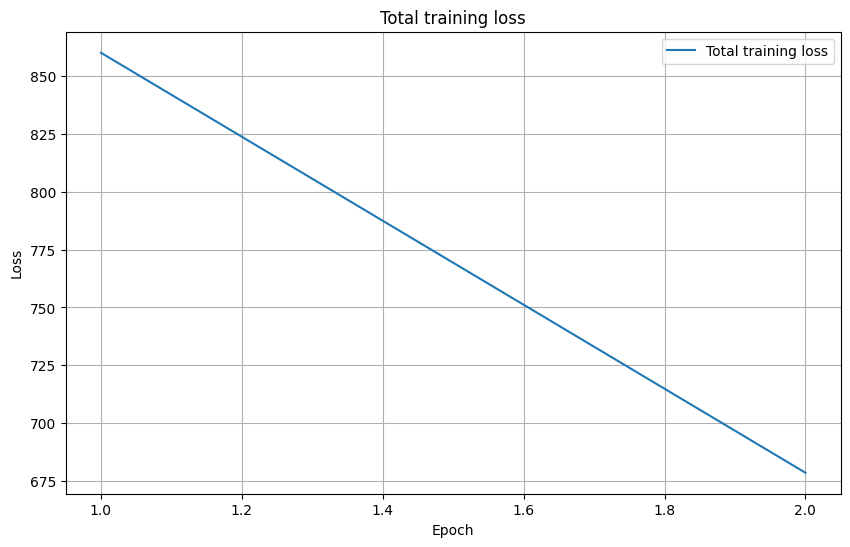

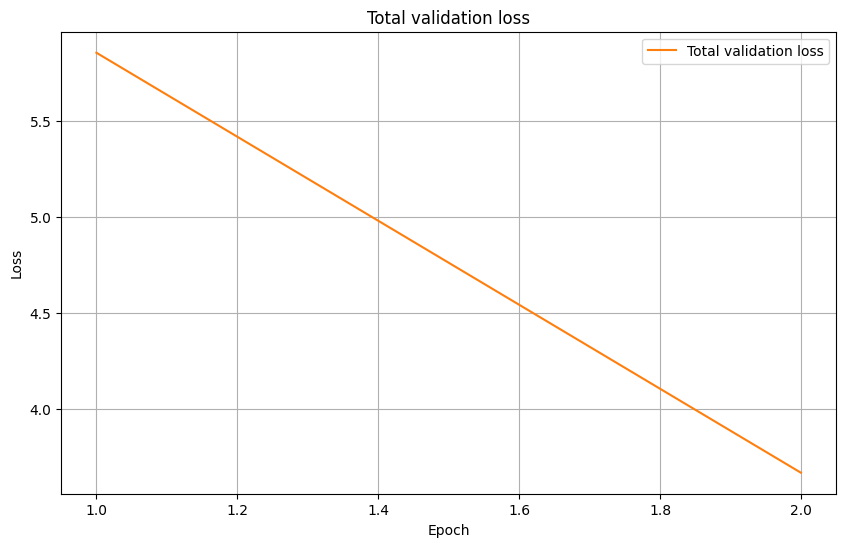

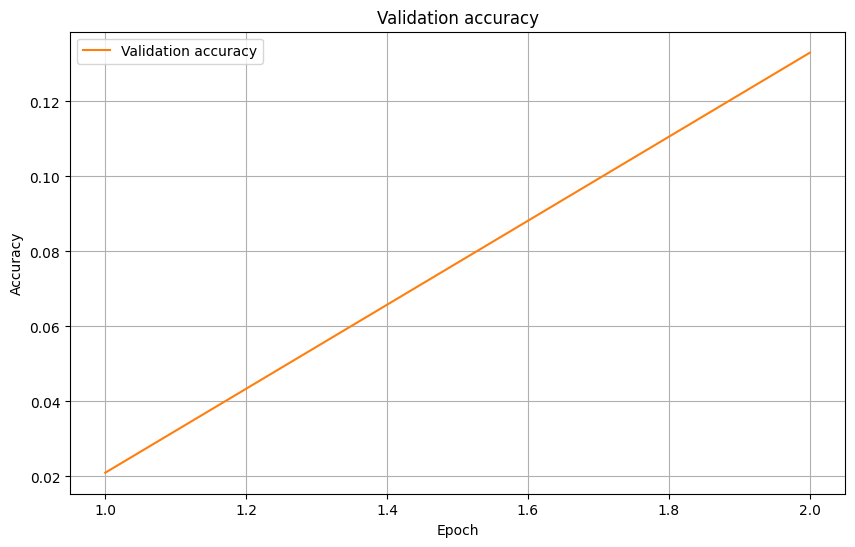

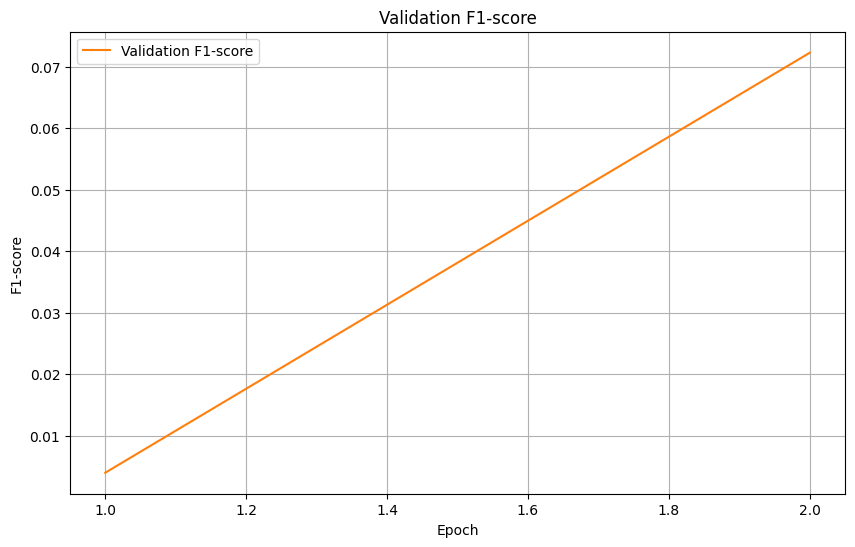

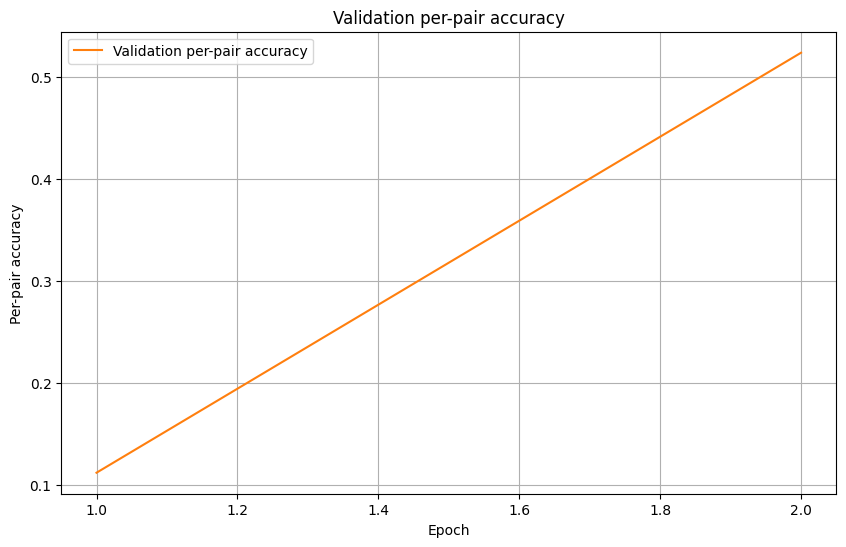

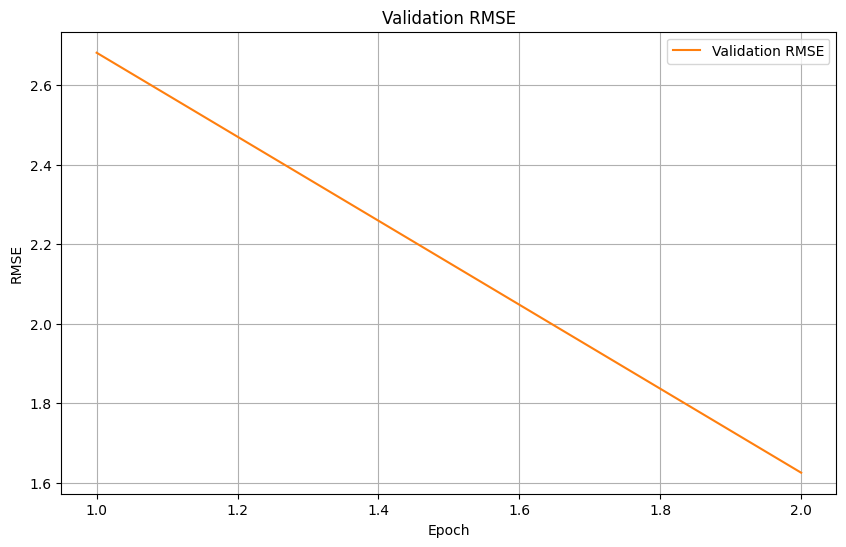

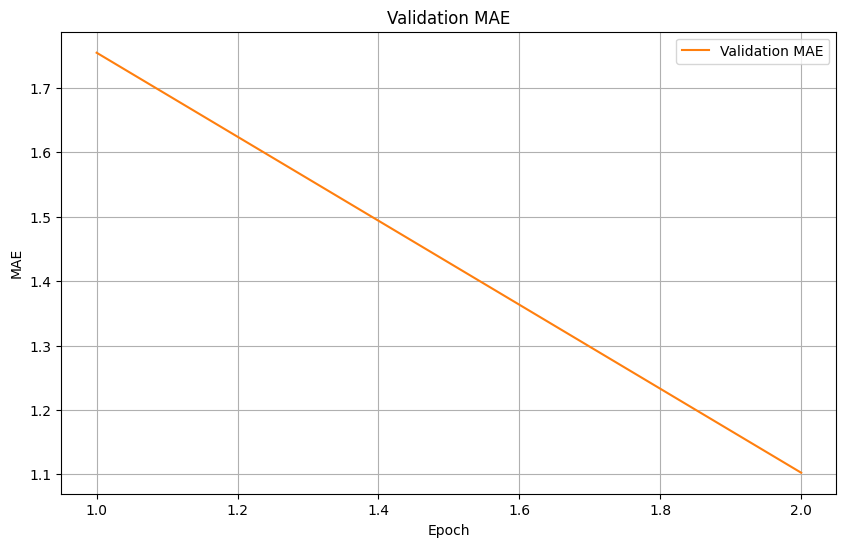

In [25]:
# PLOTS SECTION
# here is the code responsible for generating plots using data from history lists

total_epochs = len(history_avg_train_loss)
x_axis = range(1, total_epochs + 1)

# Plot 1 (Average training and validation loss)
plt.figure(figsize = (10, 6))
plt.plot(x_axis, history_avg_train_loss, label = "Average training loss")
plt.plot(x_axis, history_avg_validation_loss, label = "Average validation loss")
plt.title("Average training loss vs. Average validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot 2 (Total training loss)
plt.figure(figsize = (10, 6))
plt.plot(x_axis, history_total_train_loss, label = "Total training loss")
plt.title("Total training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot 3 (Total validation loss)
plt.figure(figsize = (10, 6))
plt.plot(x_axis, history_total_validation_loss, color = "tab:orange", label = "Total validation loss")
plt.title("Total validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot 4 (Validation accuracy)
plt.figure(figsize = (10, 6))
plt.plot(x_axis, history_validation_accuracy, color = "tab:orange", label = "Validation accuracy")
plt.title("Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot 5 (Validation f1 score)
plt.figure(figsize = (10, 6))
plt.plot(x_axis, history_validation_f1_score, color = "tab:orange", label = "Validation F1-score")
plt.title("Validation F1-score")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()

# Plot 6 (Validation per-pair accuracy)
plt.figure(figsize = (10, 6))
plt.plot(x_axis, history_validation_per_pair_accuracy, color = "tab:orange", label = "Validation per-pair accuracy")
plt.title("Validation per-pair accuracy")
plt.xlabel("Epoch")
plt.ylabel("Per-pair accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot 7 (Validation RMSE)
plt.figure(figsize = (10, 6))
plt.plot(x_axis, history_validation_rmse, color = "tab:orange", label = "Validation RMSE")
plt.title("Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

# Plot 8 (Validation MAE)
plt.figure(figsize = (10, 6))
plt.plot(x_axis, history_validation_mae, color = "tab:orange", label = "Validation MAE")
plt.title("Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# exactly the same as above but with 100 epochs
n_epochs = 100
train_dataset = GeometricShapesDataset(csv_file_path=csv_file_path, root_directory=data_folder, mode="train")
validation_dataset = GeometricShapesDataset(csv_file_path=csv_file_path, root_directory=data_folder, mode="validation")

train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size = 1000, shuffle=False)

# parameters for early stopping mechanism
patience = 5
epochs_without_improvement = 0
best_validation_loss = float('inf')

model.train()

for i in range(n_epochs):
  # TRAINING SECTION
  total_train_loss = 0.0

  for batch_index, (images, counts, labels) in enumerate(train_dataloader):
    images, counts, labels = images.to(device), counts.to(device), labels.to(device)

    optimizer.zero_grad()
    output_cls, output_cnt = model(images)
    loss = loss_cls(output_cls, labels) + lambda_cnt * loss_cnt(output_cnt, counts)
    loss.backward()
    optimizer.step()
    total_train_loss = total_train_loss + loss.item()

  avg_train_loss = total_train_loss / len(train_dataloader)
  print(f"Epoch {i+1}: Average training loss = {avg_train_loss}")

  # VALIDATION SECTION
  # switching to evaluation mode
  model.eval()

  # setting up for validation
  total_validation_loss = 0.0
  all_true_labels = []
  all_prediction_labels = []
  all_true_counts = []
  all_prediction_counts = []

  with torch.no_grad():
      for images, counts, labels in validation_dataloader:
        images, counts, labels = images.to(device), counts.to(device), labels.to(device)

        output_cls, output_cnt = model(images)
        loss = loss_cls(output_cls, labels) + lambda_cnt * loss_cnt(output_cnt, counts)
        total_validation_loss = total_validation_loss + loss.item()


        # saving outputs to lists
        # added '.cpu()' to prevent error while working with numpy on gpu
        # saving for cnt part
        all_prediction_counts.append(output_cnt.cpu())
        all_true_counts.append(counts.cpu())

        # saving for cls part
        predicted_labels = output_cls.argmax(dim=1)
        all_prediction_labels.append(predicted_labels.cpu())
        all_true_labels.append(labels.cpu())

  avg_validation_loss = total_validation_loss / len(validation_dataloader)

  # combing results saved in the lists
  validation_prediction_labels = torch.cat(all_prediction_labels) # tensor (1000) with all prediction labels
  validation_true_labels = torch.cat(all_true_labels)
  validation_prediction_counts = torch.cat(all_prediction_counts) # tensor (1000, 6) with all prediction counts
  validation_true_counts = torch.cat(all_true_counts)
  # these tensors will be used to calculate metrics

  # converting tensors to numpy format
  validation_prediction_labels_np = validation_prediction_labels.numpy()
  validation_true_labels_np = validation_true_labels.numpy()
  validation_prediction_counts_np = validation_prediction_counts.numpy()
  validation_true_counts_np = validation_true_counts.numpy()


  # a) calcuating metrics for classification part
  # calculating top1 accuracy
  validation_accuracy = accuracy_score(validation_true_labels_np, validation_prediction_labels_np)

  # calculating f1 score
  # introduced average = "macro", since otherwise it would result in error, because we are in multiclass environment
  validation_f1 = f1_score(validation_true_labels_np, validation_prediction_labels_np, average = 'macro', zero_division=0)

  # calculating 'per-pair accuracy'
  # it will be a bit more complicated than calculating f1 and accuracy
  # we can extract 'pair group' by dividing by 9
  true_pair_group = validation_true_labels_np // 9
  prediction_pair_group = validation_prediction_labels_np // 9

  # count cases when true_pair_group is equal to prediction_pair_group
  correct_pairs = (true_pair_group == prediction_pair_group)

  # compute 'per-pair accuracy'
  validation_per_pair_accuracy = correct_pairs.mean()

  print(f"Validation metircs: top-1 accuracy = {validation_accuracy}, f1 score = {validation_f1}, per-pair accuracy = {validation_per_pair_accuracy}")

  # b) calculating metrics for regression part
  # RMSE
  mse_loss = nn.MSELoss()
  validation_rmse = torch.sqrt(torch.tensor(mse_loss(validation_true_counts, validation_prediction_counts).item())).item()

  # MAE
  mae_loss = nn.L1Loss()
  validation_mae = mae_loss(validation_true_counts, validation_prediction_counts).item()

  print(f"Validation metircs: RMSE = {validation_rmse}, MAE = {validation_mae}")


  # Early stopping mechanism
  # the mechanism works as follows: we assume that we may wait no more that 'patience' epochs (in our case 'patience'=5) for improvement of avg_validation_loss
  # if for 'patience' epochs we observe no improvement for this metric, then we stop training
  if avg_validation_loss < best_validation_loss:
    best_validation_loss = avg_validation_loss
    epochs_without_improvement = 0
  else:
    epochs_without_improvement += 1
  # checking if we have already run out of patience
  if epochs_without_improvement >= patience:
    # executing early stopping
    break

  # switching back to training mode
  model.train()



KeyboardInterrupt: 

In [15]:
# AUGUMENTATION part
# let's implement 4 possible augumentation: horizontal flip, 90 degrees rotation, brightness/contast, gaussian noise
# first we shall focus on brigtness ans gaussian noise augumentations since they don't modify labels

# Augumentation 1 - brightness modification

# we use ColorJitter from transforms
brightness_change = 0.1

brightness_augumentation = transforms.ColorJitter(brightness = brightness_change)

# for example we may use something like this:
transform_augumentation = transforms.Compose([
    brightness_augumentation,
    transforms.ToTensor()
])

In [16]:
# Augumentation 2 - gaussian noise
# this time, in contrast to Augumentation 1, the gaussian noise augumentation wasn't implemented in transforms v1
# it's implemented in v2, we'll stick to v1 version
# therefore, we implement our own gaussian noise augumentation class

class GaussianNoise(object):
  def __init__(self, mean=0.0, std = 0.1):
    self.mean = mean
    self.std = std

  def __call__(self, tensor):
    # creating noise tensor of the same shape as input tensor
    gaussian_noise = torch.randn_like(tensor) * self.std + self.mean

    # adding noise to image
    tensor_with_noise = tensor + gaussian_noise

    # clamping values to interval (0, 1)
    tensor_with_noise = torch.clamp(tensor_with_noise, 0, 1)

    return tensor_with_noise


gaussian_noise_augumentation = GaussianNoise(mean = 0, std = 0.1)

In [24]:
# Augumentation 3 - random 90 degrees flip
# this augumentation changes our labels, therefore we must modify the GeometricShapesDataset class to adress it
# implemented wholly within GeometricShapesDataset class with this fragment of code:
"""
  ### Addressing the random 90 degrees rotation of the image
    # we have to add the part of code that will change the labels
    if self.transform is not None:
      # only some random part of images will be rotated; we set threshold at 0.3
      if torch.rand(1) < 0.3:
        # rotate the image
        image = image.rotate(Image.ROTATE_90)

        # updating the labels
        up_count = counts_tensor[2].item()
        right_count = counts_tensor[3].item()
        down_count = counts_tensor[4].item()
        left_count = counts_tensor[5].item()

        counts_tensor[2] = left_count
        counts_tensor[3] = up_count
        counts_tensor[4] = right_count
        counts_tensor[5] = down_count
"""

'\n  ### Addressing the random 90 degrees rotation of the image\n    # we have to add the part of code that will change the labels\n    if self.transform is not None:\n      # only some random part of images will be rotated; we set threshold at 0.3\n      if torch.rand(1) < 0.3:\n        # rotate the image\n        image = image.rotate(Image.ROTATE_90)\n\n        # updating the labels\n        up_count = counts_tensor[2].item()\n        right_count = counts_tensor[3].item()\n        down_count = counts_tensor[4].item()\n        left_count = counts_tensor[5].item()\n\n        counts_tensor[2] = left_count\n        counts_tensor[3] = up_count\n        counts_tensor[4] = right_count\n        counts_tensor[5] = down_count\n'

In [29]:
# Augumentation 4 - random horizontal flip
# similarly as in previous case, this augumentation requires switching labels, therefore we implement it within GeometricShapesDataset class
# the code:
"""
      ### Addressing the horizontal flip
      if torch.rand(1) < 0.3:
        image = image.transpose(Image.FLIP_LEFT_RIGHT)

        # now only 'triangle left' and 'triangle right' labels require switching

        right_count = counts_tensor[3].item()
        left_count = counts_tensor[5].item()

        counts_tensor[3] = left_count
        counts_tensor[5] = right_count
"""

"\n      ### Addressing the horizontal flip\n      if torch.rand(1) < 0.3:\n        image = image.transpose(Image.FLIP_LEFT_RIGHT)\n\n        # now only 'triangle left' and 'triangle right' labels require switching\n\n        right_count = counts_tensor[3].item()\n        left_count = counts_tensor[5].item()\n\n        counts_tensor[3] = left_count\n        counts_tensor[5] = right_count\n"

In [58]:
# defining augumentations
training_transform = transforms.Compose([
    brightness_augumentation,
    transforms.ToTensor(),
    gaussian_noise_augumentation
])
validation_transform = transforms.Compose([transforms.ToTensor()])

# loading dataset with augumentation
train_dataset = GeometricShapesDataset(csv_file_path=csv_file_path, root_directory=data_folder, mode="train", transform=training_transform)
validation_dataset = GeometricShapesDataset(csv_file_path=csv_file_path, root_directory=data_folder, mode="validation", transform=validation_transform)

train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size = 1000, shuffle=False)

In [62]:
# To run final experiments, we define function, which will be reposnsible for training
# this function will be relying on the training loop, we've develped before

def run_training(lambda_cnt, mode, n_epochs=100, lr=1e-3, patience=5):

  # inicializing model
  model = Model().to(device)
  optimizer = optim.Adam(model.parameters(), lr=lr)

  # parameters for early stopping mechanism
  epochs_without_improvement = 0
  best_validation_loss = float('inf')

  # defining loss functions
  loss_cls = nn.NLLLoss()
  loss_cnt = nn.SmoothL1Loss()

  # creating lists that will be responsible for storing data that will enable us to create plots about learnig curves
  history = {
    'avg_train_loss': [], 'total_train_loss': [],
    'avg_validation_loss': [], 'total_validation_loss': [],
    'validation_accuracy': [], 'validation_f1_score': [],
    'validation_per_pair_accuracy': [],
    'validation_rmse': [], 'validation_mae': [],
    'validation_rmse_per_class': [], 'validation_mae_per_class': []
  }

  # setting training mode
  model.train()

  # training loop
  for i in range(n_epochs):
    # TRAINING SECTION
    total_train_loss = 0.0

    for batch_index, (images, counts, labels) in enumerate(train_dataloader):
      images, counts, labels = images.to(device), counts.to(device), labels.to(device)

      optimizer.zero_grad()
      output_cls, output_cnt = model(images)

      # CHANGE - we change the loss function depending on 'mode' parameter
      if mode == "multitask":
        loss = loss_cls(output_cls, labels) + lambda_cnt * loss_cnt(output_cnt, counts)
      elif mode == "classification":
        loss = loss_cls(output_cls, labels)
      elif mode == "regression":
        loss = loss_cnt(output_cnt, counts)
      else:
        raise ValueError("The parameter 'mode' should be equal to 'multitask', 'classification' or 'regression'.")

      loss.backward()
      optimizer.step()
      total_train_loss = total_train_loss + loss.item()

    avg_train_loss = total_train_loss / len(train_dataloader)
    print(f"Epoch {i+1}: Average training loss = {avg_train_loss}")

    # updating history train loss lists
    history['avg_train_loss'].append(avg_train_loss)
    history['total_train_loss'].append(total_train_loss)

    # VALIDATION SECTION
    # switching to evaluation mode
    model.eval()

    # setting up for validation
    total_validation_loss = 0.0
    all_true_labels = []
    all_prediction_labels = []
    all_true_counts = []
    all_prediction_counts = []

    with torch.no_grad():
        for images, counts, labels in validation_dataloader:
          images, counts, labels = images.to(device), counts.to(device), labels.to(device)

          output_cls, output_cnt = model(images)
          # CHANGE - we change the loss function depending on 'mode' parameter
          if mode == "multitask":
            loss = loss_cls(output_cls, labels) + lambda_cnt * loss_cnt(output_cnt, counts)
          elif mode == "classification":
            loss = loss_cls(output_cls, labels)
          elif mode == "regression":
            loss = loss_cnt(output_cnt, counts)
          total_validation_loss = total_validation_loss + loss.item()


          # saving outputs to lists
          # added '.cpu()' to prevent error while working with numpy on gpu
          # saving for cnt part
          all_prediction_counts.append(output_cnt.cpu())
          all_true_counts.append(counts.cpu())

          # saving for cls part
          predicted_labels = output_cls.argmax(dim=1)
          all_prediction_labels.append(predicted_labels.cpu())
          all_true_labels.append(labels.cpu())

    avg_validation_loss = total_validation_loss / len(validation_dataloader)

    # combing results saved in the lists
    validation_prediction_labels = torch.cat(all_prediction_labels) # tensor (1000) with all prediction labels
    validation_true_labels = torch.cat(all_true_labels)
    validation_prediction_counts = torch.cat(all_prediction_counts) # tensor (1000, 6) with all prediction counts
    validation_true_counts = torch.cat(all_true_counts)
    # these tensors will be used to calculate metrics

    # converting tensors to numpy format
    validation_prediction_labels_np = validation_prediction_labels.numpy()
    validation_true_labels_np = validation_true_labels.numpy()
    validation_prediction_counts_np = validation_prediction_counts.numpy()
    validation_true_counts_np = validation_true_counts.numpy()


    # a) calcuating metrics for classification part
    # calculating top1 accuracy
    validation_accuracy = accuracy_score(validation_true_labels_np, validation_prediction_labels_np)

    # calculating f1 score
    # introduced average = "macro", since otherwise it would result in error, because we are in multiclass environment
    validation_f1 = f1_score(validation_true_labels_np, validation_prediction_labels_np, average = 'macro', zero_division=0)

    # calculating 'per-pair accuracy'
    # it will be a bit more complicated than calculating f1 and accuracy
    # we can extract 'pair group' by dividing by 9
    true_pair_group = validation_true_labels_np // 9
    prediction_pair_group = validation_prediction_labels_np // 9

    # count cases when true_pair_group is equal to prediction_pair_group
    correct_pairs = (true_pair_group == prediction_pair_group)

    # compute 'per-pair accuracy'
    validation_per_pair_accuracy = correct_pairs.mean()

    print(f"Validation metircs: top-1 accuracy = {validation_accuracy}, f1 score = {validation_f1}, per-pair accuracy = {validation_per_pair_accuracy}")

    # b) calculating metrics for regression part
    # RMSE
    mse_loss = nn.MSELoss()
    validation_rmse = torch.sqrt(torch.tensor(mse_loss(validation_true_counts, validation_prediction_counts).item())).item()

    # MAE
    mae_loss = nn.L1Loss()
    validation_mae = mae_loss(validation_true_counts, validation_prediction_counts).item()

    # now we have to compute RMSE and MAE per class
    # to do this we implement new errors
    squared_errors = (validation_prediction_counts - validation_true_counts) ** 2 # (1000, 6)
    absolute_errors = torch.abs(validation_prediction_counts - validation_true_counts) # (1000, 6)

    # we take mean over dim = 0
    mean_squared_errors = torch.mean(squared_errors, dim = 0) # (6)
    mean_absolute_errors = torch.mean(absolute_errors, dim = 0) # (6)

    validation_rmse_per_class = torch.sqrt(mean_squared_errors)
    validation_mae_per_class = mean_absolute_errors

    history_validation_rmse_per_class.append(validation_rmse_per_class)
    history_validation_mae_per_class.append(validation_mae_per_class)

    print(f"Validation metircs: RMSE (overall) = {validation_rmse}, MAE (overall)= {validation_mae}")
    print(f"Validation metircs: RMSE (per class) = {validation_rmse_per_class}, MAE (per class)= {validation_mae_per_class}")

    # updating history validation lists
    history['avg_validation_loss'].append(avg_validation_loss)
    history['total_validation_loss'].append(total_validation_loss)
    history['validation_accuracy'].append(validation_accuracy)
    history['validation_f1_score'].append(validation_f1)
    history['validation_per_pair_accuracy'].append(validation_per_pair_accuracy)
    history['validation_rmse'].append(validation_rmse)
    history['validation_mae'].append(validation_mae)


    # EARLY STOPPING mechanism
    # the mechanism works as follows: we assume that we may wait no more that 'patience' epochs (in our case 'patience'=5) for improvement of avg_validation_loss
    # if for 'patience' epochs we observe no improvement for this metric, then we stop training
    if avg_validation_loss < best_validation_loss:
      best_validation_loss = avg_validation_loss
      epochs_without_improvement = 0
    else:
      epochs_without_improvement += 1
    # checking if we have already run out of patience
    if epochs_without_improvement >= patience:
      # executing early stopping
      break

    # switching back to training mode
    model.train()

  return history



In [64]:
test_histories = {}

# Experiment 1
test_histories["multitask"] = run_training(lambda_cnt=1, mode="multitask", n_epochs=2)

# Experiment 2
test_histories["classification"] = run_training(lambda_cnt=0, mode="classification", n_epochs=2)

# Experiment 3
test_histories["regression"] = run_training(lambda_cnt=1, mode="regression", n_epochs=2)


Epoch 1: Average training loss = 6.133935955399317
Validation metircs: top-1 accuracy = 0.007, f1 score = 0.0016997749807897181, per-pair accuracy = 0.073
Validation metircs: RMSE (overall) = 2.812523126602173, MAE (overall)= 1.8392345905303955
Validation metircs: RMSE (per class) = tensor([2.7233, 2.7100, 2.8517, 2.8368, 2.9001, 2.8480]), MAE (per class)= tensor([1.8722, 1.8464, 1.8409, 1.8765, 1.7633, 1.8360])
Epoch 2: Average training loss = 5.480597381050705
Validation metircs: top-1 accuracy = 0.045, f1 score = 0.019532582066416976, per-pair accuracy = 0.259
Validation metircs: RMSE (overall) = 2.192246437072754, MAE (overall)= 1.5511234998703003
Validation metircs: RMSE (per class) = tensor([2.2340, 2.3707, 2.1209, 2.1696, 2.0052, 2.2357]), MAE (per class)= tensor([1.6166, 1.6078, 1.4741, 1.5884, 1.4153, 1.6047])
Epoch 1: Average training loss = 4.718134758320261
Validation metircs: top-1 accuracy = 0.012, f1 score = 0.0002258610954263128, per-pair accuracy = 0.073
Validation met